## Causal Forest Estimates of the Heterogeneous Impact of Market Tightness on Home Values After COVID-19

### Econ 726 Course Project Code Sample


**Stata pipeline:** the dataset used in this code sample is constructed in the`PreliminaryResults.do` file. The dataset is called `cf_input_acs_valueh.csv`.

### Introduction
This project investigates how pre-pandemic housing market tightness influenced post-pandemic home value growth across U.S. metropolitan areas. Pre-COVID tightness is measured using the Zillow Sale-to-List Ratio (SLR). The analysis combines ACS metropolitan characteristics with Zillow housing data and applies Causal Forest methodology with honest trees to estimate heterogeneous treatment effects of housing market tightness, conditional on pre-pandemic regional characteristics.

In [68]:
# Setup
#----------------------------------------------------------
from __future__ import annotations

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_STATE = 748
np.random.seed(RANDOM_STATE)

# Replace with your path
#----------------------------------------------------------
DATA_DIR = Path(".")

def assert_exists(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
        
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

def savefig(name: str):
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved figure:", out)

#-------------------------------------------------------------
# Files 
#-------------------------------------------------------------
IPUMS_ONLY = DATA_DIR / "Ipumsonly.csv"
ZILLOW_ONLY = DATA_DIR / "zillowonly.csv"
CF_INPUT = DATA_DIR / "cf_input_acs_valueh.csv"

for p in [IPUMS_ONLY, ZILLOW_ONLY, CF_INPUT]:
    assert_exists(p)

print("Found:", IPUMS_ONLY.name, ZILLOW_ONLY.name, CF_INPUT.name)

Found: Ipumsonly.csv zillowonly.csv cf_input_acs_valueh.csv


## 1. Load Dataset

In [69]:
df = pd.read_csv(CF_INPUT)
df.columns = [c.strip().lower() for c in df.columns]

print("Raw shape:", df.shape)
display(df.head())
print("Columns:", list(df.columns))

df_cf = df_cf.dropna(subset=[y_col, t_col] + covariate_cols)
print("Final sample size:", df_cf.shape[0])

Raw shape: (206, 20)


,acs_met2013,pre_covid_slr,hhinc,pov,college,employed,renter,age25_44,age45_64,commute,density,vacancy,valueh,rooms,bedrooms,valueh_pre,valueh_post,log_value_change,met2013,statefip
0,"akron, oh",0.980155,322883.752839,304.79730,0.231130,0.492067,0.296848,0.233701,0.289592,10.598121,1918.266496,0,3.391187e+06,6.596783,3.954026,3.363488e+06,3.121559e+06,-0.074646,"Akron, OH",39
1,"albany-schenectady-troy, ny",0.986779,498697.958862,337.34070,0.282874,0.510135,0.313736,0.238862,0.284334,11.030820,1791.160535,0,3.758387e+06,6.261736,3.846730,3.639203e+06,3.459369e+06,-0.050679,"Albany-Schenectady-Troy, NY",36
2,"albuquerque, nm",0.986083,201754.217856,287.96835,0.234415,0.457202,0.291531,0.264744,0.263169,10.170887,2687.427331,0,3.316169e+06,5.907648,3.948770,3.281020e+06,2.965397e+06,-0.101143,"Albuquerque, NM",35
3,"allentown-bethlehem-easton, pa-nj",0.977587,351862.692839,322.13678,0.208142,0.488804,0.286071,0.238973,0.281783,12.761364,2633.260234,0,3.437238e+06,6.522995,4.010831,3.437931e+06,3.276883e+06,-0.047977,"Allentown-Bethlehem-Easton, PA-NJ",34
4,"amarillo, tx",0.982770,483815.968208,288.33020,0.161507,0.478499,0.329429,0.274373,0.232142,8.896444,1386.967271,0,3.897393e+06,5.529396,3.741474,3.942259e+06,3.588754e+06,-0.093949,"Amarillo, TX",48


Columns: ['acs_met2013', 'pre_covid_slr', 'hhinc', 'pov', 'college', 'employed', 'renter', 'age25_44', 'age45_64', 'commute', 'density', 'vacancy', 'valueh', 'rooms', 'bedrooms', 'valueh_pre', 'valueh_post', 'log_value_change', 'met2013', 'statefip']
Final sample size: 206


## 2. Define variables

In [70]:
y_col = "log_value_change"
t_col = "pre_covid_slr"   # treatment used in your causal forest code

covariate_cols = [
    "hhinc", "pov", "college", "employed", "renter",
    "age25_44", "age45_64", "commute",
    "density", "vacancy", "valueh", "rooms", "bedrooms"
]

id_col = "acs_met2013" if "acs_met2013" in df.columns else None

needed = [y_col, t_col] + covariate_cols + ([id_col] if id_col else [])
missing = [c for c in needed if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in {CF_INPUT.name}: {missing}")

df_cf = df[needed].copy()

# Drop missing + non-finite
df_cf = df_cf.dropna(subset=[y_col, t_col] + covariate_cols).copy()
num = df_cf[[y_col, t_col] + covariate_cols].to_numpy()
df_cf = df_cf.loc[np.isfinite(num).all(axis=1)].reset_index(drop=True)

print("Analysis frame shape:", df_cf.shape)
display(df_cf.head())

Analysis frame shape: (206, 16)


,log_value_change,pre_covid_slr,hhinc,pov,college,employed,renter,age25_44,age45_64,commute,density,vacancy,valueh,rooms,bedrooms,acs_met2013
0,-0.074646,0.980155,322883.752839,304.79730,0.231130,0.492067,0.296848,0.233701,0.289592,10.598121,1918.266496,0,3.391187e+06,6.596783,3.954026,"akron, oh"
1,-0.050679,0.986779,498697.958862,337.34070,0.282874,0.510135,0.313736,0.238862,0.284334,11.030820,1791.160535,0,3.758387e+06,6.261736,3.846730,"albany-schenectady-troy, ny"
2,-0.101143,0.986083,201754.217856,287.96835,0.234415,0.457202,0.291531,0.264744,0.263169,10.170887,2687.427331,0,3.316169e+06,5.907648,3.948770,"albuquerque, nm"
3,-0.047977,0.977587,351862.692839,322.13678,0.208142,0.488804,0.286071,0.238973,0.281783,12.761364,2633.260234,0,3.437238e+06,6.522995,4.010831,"allentown-bethlehem-easton, pa-nj"
4,-0.093949,0.982770,483815.968208,288.33020,0.161507,0.478499,0.329429,0.274373,0.232142,8.896444,1386.967271,0,3.897393e+06,5.529396,3.741474,"amarillo, tx"


## 3. Dataset Analysis

**Market Tightness Distribution**
We find the distribution of SLR across MSAs to be mostly left skewed, with a few nontrivial outliers that showed average home selling around 104% over asking price. The density plot shown by Figure 2 displays a tight range between 96% and 100%, therefore we might see less obvious heterogenous effects across groups as we increase the amount of buckets we compare MSAs across. This is an early sign before our analysis that could signal a need for more data to proxy market desirability (amenities, access to credit, environmental considerations, etc.).

**Home Value Distribution**
Average reported home values in each MSA between 2016-2022 decreased. However, during this time, if there was a strong buyer’s market, this could be reflecting more homeownership or more affordable housing being built across MSAs in response to housing needs. This dataset also relies on self-reported data. That could mean that home valuations are inaccurate or outdated. Commercial data could reveal a more accurate picture of true market-values of owned and occupied housing (for the purposes of this coding sample, commercial data is not included).

**Covariate Mapping**
Employment, poverty, education, and aged between 45-64, shows strong correlation with density. This suggests there may be some confounding variables between densely populated cities with greater resources (better public transportation, stronger welfare programs, and more job opportunities within a well-developed agglomeration). However, because we will use double machine learning method, our goal would be to use these variables as a way to model desireability of living in such a location as part of it's causal inference.

Saved figure: figures/slr_distribution.png


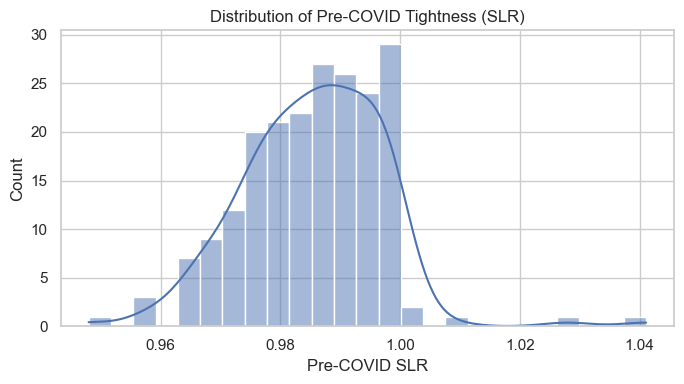

Saved figure: figures/outcome_distribution.png


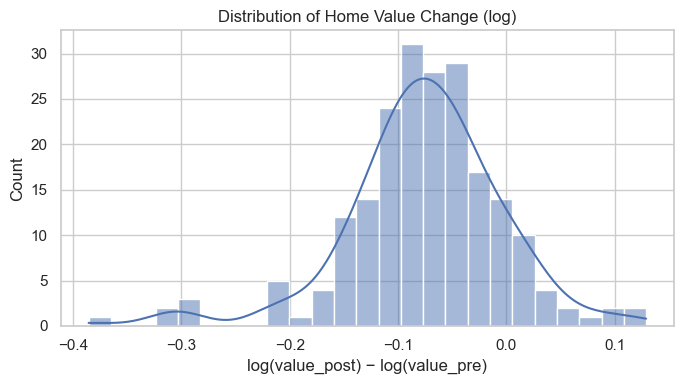

Saved figure: figures/corr_heatmap.png


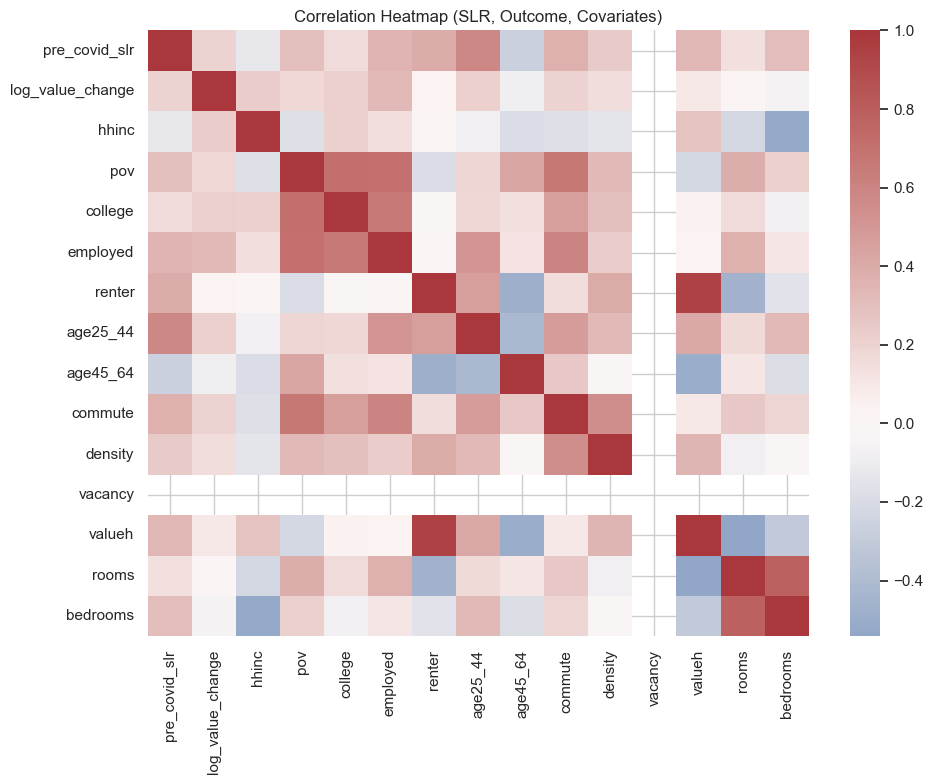

In [71]:
# Market Tightness Distribution (Sale-to-List Price Ratio - SLR)
plt.figure(figsize=(7,4))
sns.histplot(df_cf[t_col], bins=25, kde=True)
plt.title("Distribution of Pre-COVID Tightness (SLR)")
plt.xlabel("Pre-COVID SLR")
savefig("slr_distribution.png")
plt.show()

# Home Value Distribution
plt.figure(figsize=(7,4))
sns.histplot(df_cf[y_col], bins=25, kde=True)
plt.title("Distribution of Home Value Change (log)")
plt.xlabel("log(value_post) − log(value_pre)")
savefig("outcome_distribution.png")
plt.show()

# Correlation
eda_cols = [t_col, y_col] + covariate_cols
corr = df_cf[eda_cols].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Correlation Heatmap (SLR, Outcome, Covariates)")
savefig("corr_heatmap.png")
plt.show()



## 4. Predictive baselines (Using Ridge and Random Forest)

As a benchmark, I fit Ridge regression and a Random Forest to predict MSA-level home value change using our observed covariates and market tightness (SLR) variable. 

The Ridge specification achieves  $ RMSE \enspace \approx 0.075  $ (log points) and $ R^2 \approx 0.021 $. Low predicted indicating limited explanatory power under a linear specification. 

The Random Forest specification does little to improve variation in prediction error but offers modeslty improved prediction power ($ RMSE \approx 0.072 \enspace and \enspace R^2 \approx 0.097$, and  5-fold Cross-validation $ RMSE \approx 0.068  $.



In [72]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df_cf[covariate_cols + [t_col]].copy()
y = df_cf[y_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), X.columns.tolist())
    ],
    remainder="drop"
)

ridge = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE))
])

rf = Pipeline(steps=[
    ("preprocess", preprocess),  # scaling not needed for RF but OK
    ("model", RandomForestRegressor(
        n_estimators=800, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
    ))
])

ridge.fit(X_train, y_train)
pred_r = ridge.predict(X_test)
print("Ridge  RMSE:", mean_squared_error(y_test, pred_r, squared=False))
print("Ridge  R^2 :", r2_score(y_test, pred_r))

rf.fit(X_train, y_train)
pred_f = rf.predict(X_test)
print("RF     RMSE:", mean_squared_error(y_test, pred_f, squared=False))
print("RF     R^2 :", r2_score(y_test, pred_f))

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg_rmse = cross_val_score(rf, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
print("RF CV RMSE (mean, std):", float((-neg_rmse).mean()), float((-neg_rmse).std()))

Ridge  RMSE: 0.07534654091731631
Ridge  R^2 : 0.020828595212360468
RF     RMSE: 0.07233689080963544
RF     R^2 : 0.09749054632897092
RF CV RMSE (mean, std): 0.06793224848625526 0.00289932386159155


## 5. Causal Forest

Below I fit a Causal Forest model to our standardized, observed covariates and centered treatment effect (SLR), to observe changes in average change in reported home values. 

In [73]:
# Setup
#------------------------------------------------
import numpy as np
import pandas as pd

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
    
Y = df_cf[y_col].to_numpy()                  # Outcome
T = df_cf[t_col].to_numpy().ravel()
T_centered = T - T.mean()   # Centered Treatment
X_raw = df_cf[covariate_cols].to_numpy()     # Covariates

# Standardize covariates
#------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)
    


# Nuisance Model
#------------------------------------------------
model_y = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=5, min_samples_split=10,
    random_state=RANDOM_STATE, n_jobs=-1
)

model_t = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=5, min_samples_split=10,
    random_state=RANDOM_STATE, n_jobs=-1
)

est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=2000,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    verbose=0
)

# Fit with bag of little bags
#------------------------------------------------
est.fit(Y, T_centered, X=X_std, inference="blb")

# Report ATE
#------------------------------------------------
tau_hat = est.effect(X_std).ravel()
df_cf["tau_hat"] = tau_hat

print("ATE (mean CATE):", float(np.mean(tau_hat)))
print("SD(CATE):", float(np.std(tau_hat)))
print("MIN (CATE):", float(np.min(tau_hat)))
print("MAX (CATE):", float(np.max(tau_hat)))

# Treatment Intervals
#------------------------------------------------
lb, ub = est.effect_interval(X_std, alpha=0.05)
df_cf["tau_ci_lower"] = lb.ravel()
df_cf["tau_ci_upper"] = ub.ravel()
print("Saved 95% CATE intervals to df_cf.")



ATE (mean CATE): 1.1684162285175719
SD(CATE): 0.4261298516155329
MIN (CATE): 0.10815782770479791
MAX (CATE): 2.779285076644234
Saved 95% CATE intervals to df_cf.


## 6. CATE Analysis

**Conditional Average Treatment Effect**
The mean CATE across all MSAs is $\hat{\tau} = 1.168$ with a standard deviation of $ \approx 0.426 $. This seems to suggest strong heterogeneity, as it indicates a dispersion
around 36.5% around the mean coefficient. 

The most responsive MSAs exhibit treatment effects above
2.79% incrase in home values, while the least responsive MSAs show effects below 0.10% increase in home values.

The CATE curve however only slightly indicates a generally upward-sloping relationship between
SLR and the marginal effect of SLR on home value changes. At very low and very high levels of
tightness, the estimates are smoother and more stable, while the middle of the distribution exhibits wider confidence intervals and varies greatly. This pattern could reflect greater uncertainty in regions where many observations share similar treatment levels but have very different covariate profiles, making local slope estimation more difficult despite strong treatment overlap.


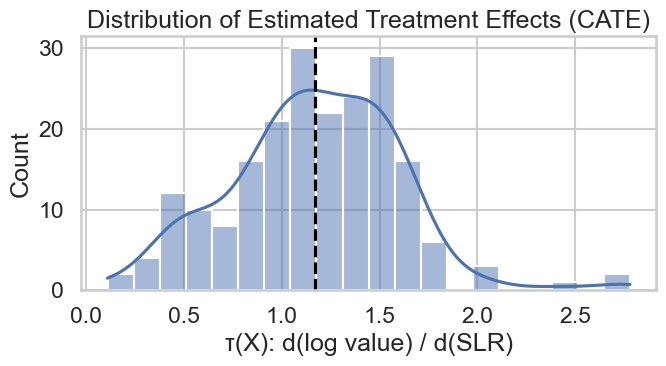

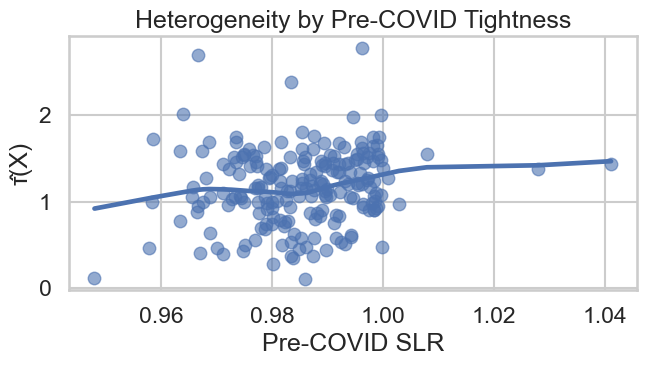


Top 10 MSAs by CATE:


,acs_met2013,pre_covid_slr,log_value_change,tau_hat
197,"wenatchee, wa",0.996140,0.129208,2.779285
135,"parkersburg-vienna, wv",0.966610,-0.385749,2.701889
114,"monroe, mi",0.983351,-0.047710,2.386358
75,"homosassa springs, fl",0.963872,-0.092855,2.019147
128,"ogden-clearfield, ut",0.999639,0.091205,2.003667
29,"burlington-south burlington, vt",0.994631,0.112462,1.983402
81,"jackson, mi",0.985330,-0.074401,1.800620
179,"st. george, ut",0.987573,-0.134441,1.758885
16,"barnstable town, ma",0.973552,-0.076221,1.751800
203,"york-hanover, pa",0.998125,0.002169,1.751099



Bottom 10 MSAs by CATE:


,acs_met2013,pre_covid_slr,log_value_change,tau_hat
178,"springfield, oh",0.985934,-0.207728,0.108158
170,"scranton--wilkes-barre--hazleton, pa",0.947995,-0.015699,0.114531
190,"tyler, tx",0.980245,-0.174632,0.278588
67,"greensboro-high point, nc",0.983758,-0.126941,0.347348
200,"winston-salem, nc",0.983459,-0.096989,0.367636
48,"dayton, oh",0.987310,-0.110889,0.374727
115,"montgomery, al",0.971202,-0.093429,0.390126
55,"erie, pa",0.966984,-0.059208,0.403134
186,"toledo, oh",0.974739,-0.104652,0.424401
116,"muskegon, mi",0.989716,-0.179427,0.434393


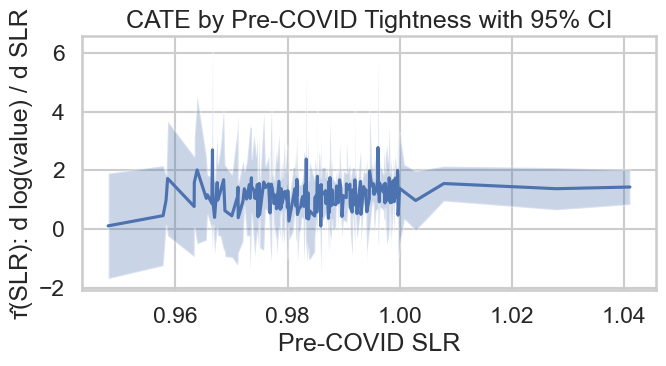

Saved: cf_results_with_tau.csv, gate_by_slr_quartile.csv


In [75]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")


#------------------------------------------------------------
# CATE Distribution
#------------------------------------------------------------
plt.figure(figsize=(7,4))
sns.histplot(df_cf["tau_hat"], bins=20, kde=True)
plt.axvline(df_cf["tau_hat"].mean(), color="black", linestyle="--")
plt.title("Distribution of Estimated Treatment Effects (CATE)")
plt.xlabel("τ(X): d(log value) / d(SLR)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



#------------------------------------------------------------
# Treatment v. CATE Scatter
#------------------------------------------------------------
plt.figure(figsize=(7,4))
sns.regplot(
    data=df_cf,
    x=t_col,
    y="tau_hat",
    lowess=True,
    scatter_kws={"alpha":0.6}
)

plt.title("Heterogeneity by Pre-COVID Tightness")
plt.xlabel("Pre-COVID SLR")
plt.ylabel("τ̂(X)")
plt.tight_layout()
plt.show()



#------------------------------------------------------------
# Top 10 and Bottom 10 MSAs by CATE
#------------------------------------------------------------
show_cols = [c for c in [id_col, t_col, y_col, "tau_hat"] if c]

print("\nTop 10 MSAs by CATE:")
display(df_cf[show_cols].sort_values("tau_hat", ascending=False).head(10))

print("\nBottom 10 MSAs by CATE:")
display(df_cf[show_cols].sort_values("tau_hat", ascending=True).head(10))


#------------------------------------------------------------
# CATE Plot
#------------------------------------------------------------
plot_df = df_cf[[t_col, "tau_hat", "tau_ci_lower", "tau_ci_upper"]].dropna()
plot_df = plot_df.sort_values(t_col)

plt.figure(figsize=(7,4))
sns.lineplot(data=plot_df, x=t_col, y="tau_hat")
plt.fill_between(
    plot_df[t_col],
    plot_df["tau_ci_lower"],
    plot_df["tau_ci_upper"],
    alpha=0.3
)
plt.title("CATE by Pre-COVID Tightness with 95% CI")
plt.xlabel("Pre-COVID SLR")
plt.ylabel("τ̂(SLR): d log(value) / d SLR")
plt.tight_layout()
plt.show()


#------------------------------------------------------------
# Save Outputs
#------------------------------------------------------------
df_cf.to_csv(DATA_DIR / "cf_results_with_tau.csv", index=False)
gate.to_csv(DATA_DIR / "gate_by_slr_quartile.csv", index=False)
print("Saved: cf_results_with_tau.csv, gate_by_slr_quartile.csv")

# 7. GATE Analysis
**Group Average Treatment Effect**
The GATE estimates with 95% confidence intervals. The pattern is nearly monotonic,
but suffers a slight dip the estimated from Q1 to Q2 (from $ \hat{\tau} \approx 1.175$ and  $ \hat{\tau} \approx 1.042$ respectively). This means that the less competitive markets do not appear the most sensitive to change. 

However, from Q2 onward the relationship becomes strictly monotonic. Treatment effects rise from Q2 to Q3 and continue to increase substantially into the tightest quartile (Q4), which displays the largest effect ( $ \hat{\tau} \approx 1.331$).

The difference between Q2 and Q4 is both economically meaningful and statistically significant,
and the overall pattern indicates that housing markets with greater pre-COVID tightness exhibit
stronger responsiveness of home values to changes in SLR.

**GATE Hetoregeneity Tests (Welch's T-Test)***
Welch tests show significant heterogeneity between Q2 and Q4 (tightest) groups,($p_{\text{adj}}=0.008$). We find a 1% change in SLR is associated with a .27% increase in home value growth in Q4 relative to Q2. This implies heterogeneity is concentrated in the tightest markets relative to lower mid-tightness markets, rather than varying smoothly across quartiles.

**Variable Importance: GATE Analysis**
Variable importance from the causal forest indicates that density is the dominant driver of heterogeneity (contributes $ \approx 16.3% $ of prediction of model), followed by household income ($ \approx 13.9%$) and renter share ($ \approx 10.4% $). 

GATE estimates by density quartile show a much stronger a convex pattern, with larger effects in the lowest- and highest-density markets. This pattern is consistent with the idea of "super-star cities", where ineleastic supply results in high growth of home value. Above we found density's positive correlation with other characteristics of a region (i.e., education, employment,poverty, and renter composition), thus the variable is likely a proxy for attributes of major agglomerations.



,slr_quartile,mean,std,count,se,ci_lower,ci_upper
0,Q1 (slackest),1.175212,0.478298,52,0.066328,1.045209,1.305215
1,Q2,1.041883,0.436442,51,0.061114,0.922099,1.161666
2,Q3,1.142588,0.358107,51,0.050145,1.044304,1.240872
3,Q4 (tightest),1.311052,0.393392,52,0.054554,1.204127,1.417977


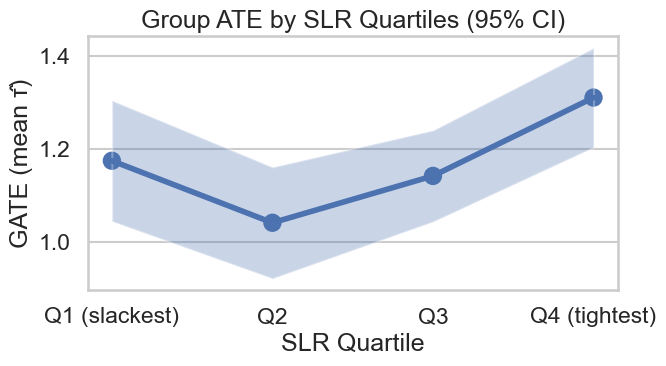


Table 2: GATE Estimates by SLR Quartile


,Quartile,Mean τ̂,Std. Dev.,Count,95% CI
0,Q1 (slackest),1.175,0.478,52,"[1.045, 1.305]"
1,Q2,1.042,0.436,51,"[0.922, 1.162]"
2,Q3,1.143,0.358,51,"[1.044, 1.241]"
3,Q4 (tightest),1.311,0.393,52,"[1.204, 1.418]"



Table 3: Pairwise Welch Tests for Heterogeneity


,Comparison,t-statistic,p-value,n_A,n_B,mean_A,mean_B,diff (A-B),p_adj (BH-FDR)
4,Q2 vs Q4 (tightest),-3.286,0.001,51,52,1.042,1.311,-0.269,0.008
5,Q3 vs Q4 (tightest),-2.274,0.025,51,52,1.143,1.311,-0.168,0.075
2,Q1 (slackest) vs Q4 (tightest),-1.582,0.117,52,52,1.175,1.311,-0.136,0.214
0,Q1 (slackest) vs Q2,1.478,0.142,52,51,1.175,1.042,0.133,0.214
3,Q2 vs Q3,-1.274,0.206,51,51,1.042,1.143,-0.101,0.247
1,Q1 (slackest) vs Q3,0.392,0.696,52,51,1.175,1.143,0.033,0.696


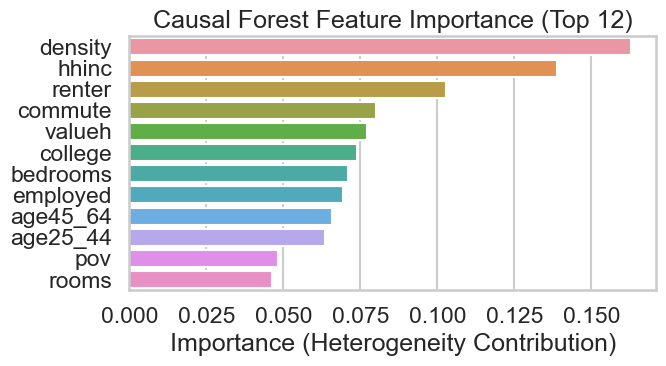

,feature,importance
8,density,0.162870
0,hhinc,0.138783
4,renter,0.102930
7,commute,0.079962
10,valueh,0.077190
2,college,0.073890
12,bedrooms,0.070966
3,employed,0.069494
6,age45_64,0.065685
5,age25_44,0.063433



GATE by Density Quartile


,density_quartile,mean,std,count,se,ci_lower,ci_upper
0,Q1 (lowest density),1.323618,0.527997,52,0.073220,1.180107,1.467129
1,Q2,0.981718,0.393069,51,0.055041,0.873839,1.089598
2,Q3,1.097298,0.408060,51,0.057140,0.985304,1.209292
3,Q4 (highest density),1.266073,0.256451,52,0.035563,1.196369,1.335777


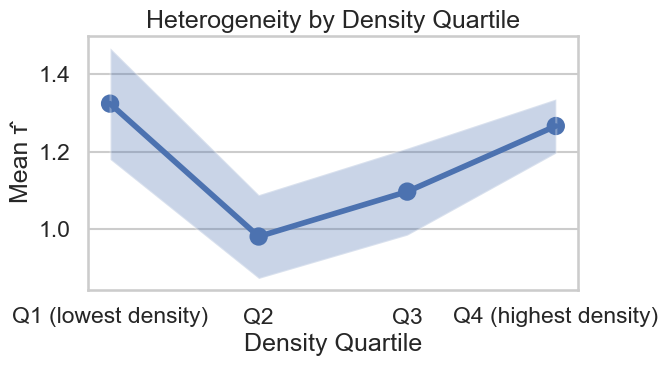

Saved: cf_results_with_tau.csv, gate_by_slr_quartile.csv


In [76]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

#------------------------------------------------------------
# GATE (SLR Quartiles from slackest to tightest)
#------------------------------------------------------------
df_cf["slr_quartile"] = pd.qcut(
    df_cf[t_col], 
    q=4,
    labels=["Q1 (slackest)", "Q2", "Q3", "Q4 (tightest)"]
    )

gate = df_cf.groupby("slr_quartile")["tau_hat"].agg(["mean", "std", "count"]).reset_index()
gate["se"] = gate["std"] / np.sqrt(gate["count"])
gate["ci_lower"] = gate["mean"] - 1.96 * gate["se"]
gate["ci_upper"] = gate["mean"] + 1.96 * gate["se"]

display(gate)

#------------------------------------------------------------
# Plot GATE
#------------------------------------------------------------
plt.figure(figsize=(7,4))
sns.pointplot(data=gate, x="slr_quartile", y="mean", join=True)

plt.fill_between(
    range(len(gate)),
    gate["ci_lower"].to_numpy(),
    gate["ci_upper"].to_numpy(),
    alpha=0.3
)

plt.title("Group ATE by SLR Quartiles (95% CI)")
plt.xlabel("SLR Quartile")
plt.ylabel("GATE (mean τ̂)")
plt.tight_layout()
plt.show()



#------------------------------------------------------------
# GATE Table by SLR Quartiles
#------------------------------------------------------------
gate_table = gate.copy()
gate_table["mean"] = gate_table["mean"].round(3)
gate_table["std"] = gate_table["std"].round(3)
gate_table["ci_lower"] = gate_table["ci_lower"].round(3)
gate_table["ci_upper"] = gate_table["ci_upper"].round(3)

gate_table["95% CI"] = (
    "[" + gate_table["ci_lower"].astype(str) +
    ", " + gate_table["ci_upper"].astype(str) + "]"
)

gate_table = gate_table.rename(columns={
    "slr_quartile": "Quartile",
    "mean": "Mean τ̂",
    "std": "Std. Dev.",
    "count": "Count"
})

gate_table = gate_table[["Quartile", "Mean τ̂", "Std. Dev.", "Count", "95% CI"]]

print("\nTable 2: GATE Estimates by SLR Quartile")
display(gate_table)


#------------------------------------------------------------
# Pairwise Welch T-tests
#------------------------------------------------------------
from itertools import combinations
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np


quartiles = df_cf["slr_quartile"].cat.categories.tolist()

pairwise_results = []
for qA, qB in combinations(quartiles, 2):
    gA = df_cf.loc[df_cf["slr_quartile"] == qA, "tau_hat"].dropna()
    gB = df_cf.loc[df_cf["slr_quartile"] == qB, "tau_hat"].dropna()

    t_stat, p_val = ttest_ind(gA, gB, equal_var=False)  # Welch

    pairwise_results.append({
        "Comparison": f"{qA} vs {qB}",
        "t-statistic": float(t_stat),
        "p-value": float(p_val),
        "n_A": int(gA.shape[0]),
        "n_B": int(gB.shape[0]),
        "mean_A": float(gA.mean()),
        "mean_B": float(gB.mean()),
        "diff (A-B)": float(gA.mean() - gB.mean()),
    })

welch_all = pd.DataFrame(pairwise_results)


# BH-FDR, controlling average false positives
#-----------------------------------------------------------
from statsmodels.stats.multitest import multipletests
welch_all["p_adj (BH-FDR)"] = multipletests(welch_all["p-value"], method="fdr_bh")[1]


# Display
#-------------------------------------------------------------
welch_all["t-statistic"] = welch_all["t-statistic"].round(3)
welch_all["p-value"] = welch_all["p-value"].round(3)
welch_all["p_adj (BH-FDR)"] = welch_all["p_adj (BH-FDR)"].round(3)
welch_all["mean_A"] = welch_all["mean_A"].round(3)
welch_all["mean_B"] = welch_all["mean_B"].round(3)
welch_all["diff (A-B)"] = welch_all["diff (A-B)"].round(3)

print("\nTable 3: Pairwise Welch Tests for Heterogeneity")
display(welch_all.sort_values("p-value"))



#------------------------------------------------------------
# Variable Importance
#------------------------------------------------------------
importances = est.feature_importances_
importances = np.asarray(importances).ravel()

cf_imp = pd.DataFrame({
    "feature": covariate_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=cf_imp.head(12), x="importance", y="feature")
plt.title("Causal Forest Feature Importance (Top 12)")
plt.xlabel("Importance (Heterogeneity Contribution)")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(cf_imp)

#------------------------------------------------------------
# Variable Importance GATE Review
#------------------------------------------------------------

# Density quartiles
#--------------------------------------------------
df_cf["density_quartile"] = pd.qcut(
    df_cf["density"],
    q=4,
    labels=["Q1 (lowest density)", "Q2", "Q3", "Q4 (highest density)"]
)

gate_density = (
    df_cf.groupby("density_quartile")["tau_hat"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

gate_density["se"] = gate_density["std"] / np.sqrt(gate_density["count"])
gate_density["ci_lower"] = gate_density["mean"] - 1.96 * gate_density["se"]
gate_density["ci_upper"] = gate_density["mean"] + 1.96 * gate_density["se"]

print("\nGATE by Density Quartile")
display(gate_density)

# Plot GATE
#---------------------------------------------------
plt.figure(figsize=(7,4))
sns.pointplot(data=gate_density, x="density_quartile", y="mean")
plt.fill_between(
    range(len(gate_density)),
    gate_density["ci_lower"],
    gate_density["ci_upper"],
    alpha=0.3
)
plt.title("Heterogeneity by Density Quartile")
plt.xlabel("Density Quartile")
plt.ylabel("Mean τ̂")
plt.tight_layout()
plt.show()


#------------------------------------------------------------
# Save Outputs
#------------------------------------------------------------
df_cf.to_csv(DATA_DIR / "cf_results_with_tau.csv", index=False)
gate.to_csv(DATA_DIR / "gate_by_slr_quartile.csv", index=False)
print("Saved: cf_results_with_tau.csv, gate_by_slr_quartile.csv")

##  Orthogonality and Residualization 

Approximately $R^2 = 0.49$ of the variation in pre-COVID SLR is predictable from observed covariates, indicating substantial overlap between the treatment and observable characteristics and motivating adjustment for confounding. 

After residualization, correlations between the orthogonalized treatment and covariates are near zero ($|corr| < 0.004$), providing empirical evidence that the orthogonalization step successfully removes linear dependence between treatment and controls. This supports the Neyman orthogonality condition underlying the Causal Forest double machine learning framework.

R^2 of treatment model (T ~ X): 0.4874765743052406


/Users/maciwoyat/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maciwoyat/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,covariate,"corr(resid_T, Xj)"
1,pov,0.003818
5,age25_44,0.002142
2,college,-0.001469
12,bedrooms,0.001320
10,valueh,0.001305
4,renter,0.001093
6,age45_64,-0.000774
8,density,-0.000618
0,hhinc,0.000309
3,employed,-0.000270


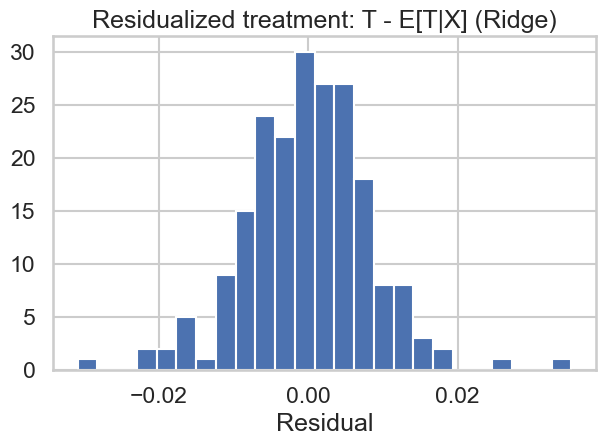

In [77]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

X_cov = df_cf[covariate_cols].to_numpy()
T_vec = df_cf[t_col].to_numpy()

# Standardize x
X_cov_std = StandardScaler().fit_transform(X_cov)

# Check for Confounding
t_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
t_model.fit(X_cov_std, T_vec)
T_hat = t_model.predict(X_cov_std)
r2_t = r2_score(T_vec, T_hat)
T_resid = T_vec - T_hat

print("R^2 of treatment model (T ~ X):", float(r2_t))

# Correlation of residualized T with covariates
corrs = []
for j, col in enumerate(covariate_cols):
    xj = X_cov_std[:, j]
    corr = np.corrcoef(T_resid, xj)[0, 1]
    corrs.append((col, float(corr)))

corr_df = pd.DataFrame(corrs, columns=["covariate", "corr(resid_T, Xj)"]).sort_values(
    "corr(resid_T, Xj)", key=lambda s: np.abs(s), ascending=False
)
display(corr_df.head(15))

plt.figure()
plt.hist(T_resid, bins=25)
plt.title("Residualized treatment: T - E[T|X] (Ridge)")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()